This notebook contains Helen's python code for loading and getting counts of the DC Inbox newletter content files for the election integrity project.

In [64]:
# import libraries
import pandas as pd
import csv
import os

# For figures
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick   
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.transforms import offset_copy
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# For predictions / linear regression plots
import sys
import statsmodels.api as sm
# For tables
from IPython.display import display, HTML
import dataframe_image as dfi
from matplotlib.colors import LinearSegmentedColormap

In [16]:
# Read in the raw DCInbox table

dcinbox_files = [
    "dcinbox_export_111_partial_b2",
    "dcinbox_export_112_b2",
    "dcinbox_export_113_b2",
    "dcinbox_export_114_b2",
    "dcinbox_export_115_b2",
    "dcinbox_export_116_b2",
    "dcinbox_export_117_b2",
    "dcinbox_export_118_b2",
    "dcinbox_export_119th_through9_19_2025_b2"
]

file_directory = "..\data\dcinbox"

dcinbox_raw_df = None

for file in dcinbox_files:

    current_file_path = os.path.join(file_directory, file + ".csv")
    print(current_file_path)

    current_df = pd.read_csv(current_file_path,
                            quotechar = '"',   # Make sure actual quotation marks in newsletters are handled right
                            encoding = "cp1252",
                            engine = 'python'    # This might be able to handle very long messages better
    )

    dcinbox_raw_df = pd.concat([dcinbox_raw_df, current_df])

# Remove all unnamed columns, because they're messing up the read of the file
unnamed = dcinbox_raw_df.columns.str.contains('^Unnamed')
dcinbox_clean_columns_df = dcinbox_raw_df.loc[:, ~unnamed].copy()

dcinbox_clean_columns_df.head()

..\data\dcinbox\dcinbox_export_111_partial_b2.csv
..\data\dcinbox\dcinbox_export_112_b2.csv
..\data\dcinbox\dcinbox_export_113_b2.csv
..\data\dcinbox\dcinbox_export_114_b2.csv
..\data\dcinbox\dcinbox_export_115_b2.csv
..\data\dcinbox\dcinbox_export_116_b2.csv
..\data\dcinbox\dcinbox_export_117_b2.csv
..\data\dcinbox\dcinbox_export_118_b2.csv
..\data\dcinbox\dcinbox_export_119th_through9_19_2025_b2.csv


,Subject,Body,Unix Timestamp,BioGuide ID,Congress,First Name,Last Name,Date of Birth,Gender,State,District,Party,Chamber,Nickname,ID,Body_2
0,In Case You Missed It: Congresswoman Miller di...,Congresswoman Candice Miller ~ Newsletter - S...,1294093079000,M001150,112,Candice,Miller,5/7/1954,F,MI,10.0,Republican,House,NaN,63872,NaN
1,Congresswoman Candice Miller: New Congress Beg...,Congresswoman Candice Miller ~ Newsletter - S...,1294075081000,M001150,112,Candice,Miller,5/7/1954,F,MI,10.0,Republican,House,NaN,63875,NaN
2,"News From Senator Begich; January 3, 2011: Hap...","january 15, 2011 Anchorage Covenant House Fir...",1294074905000,B001265,112,Mark,Begich,3/30/1962,M,AK,NaN,Democrat,Senate,NaN,63874,NaN
3,e-Newsletter from Congressman Dutch Ruppersberger,E-Newsletter ~ Dutch Ruppersberger Representi...,1294074176000,R000576,112,C.,Ruppersberger,1/31/1946,M,MD,2.0,Democrat,House,NaN,63876,NaN
4,"Randy`s Roundup - January 3, 2011",If you are having trouble viewing this messag...,1294064867000,N000182,112,Randy,Neugebauer,12/24/1949,M,TX,19.0,Republican,House,NaN,63873,NaN


In [17]:
# QC to make sure special characters are coming in okay

mask = dcinbox_clean_columns_df["Last Name"].str.contains(r'[^\x00-\x7F]', regex=True, na=False)
special_names = dcinbox_clean_columns_df[mask]

# Select only first and last name, and keep unique combinations
allowed_parties = ["Democrat", "Republican", "Other"]
unique_names = special_names[special_names["Party"].isin(allowed_parties)][["First Name", "Last Name", "Party"]].drop_duplicates()

print(unique_names)

     First Name         Last Name       Party
875         Ben            Luj?°n    Democrat
1866      Linda          S?°nchez    Democrat
5803      Nydia        Vel?°zquez    Democrat
68         Beto        O‚ÄôRourke    Democrat
175        Tony         C?°rdenas    Democrat
383     Nanette         Barrag?°n    Democrat
819         Tom      O‚ÄôHalleran    Democrat
8648       Luis        Guti?©rrez    Democrat
763   Jenniffer  Gonz?°lez-Col??n  Republican


In [18]:
# QC to find duplicates in DC Inbox ID field - it turns out they're all the split records

print(len(dcinbox_clean_columns_df))
print(dcinbox_clean_columns_df["ID"].nunique())

duplicates = dcinbox_clean_columns_df[dcinbox_clean_columns_df["ID"].duplicated(keep=False)]
print(duplicates.head())


205862
205848
                                        Subject  \
12175             Defending Those Who Defend Us   
0                                Weekly Wrap Up   
1      Your 2021 Survey | A New Congress Begins   
2             Priorities for the 117th Congress   
3                             Let's Get to Work   

                                                    Body Unix Timestamp  \
12175   _pnh_container _pnh_mark { DISPLAY: none !imp...            NaN   
0       Weekly Wrap Up Dear Neighbor, Happy New Year!...  1609714699000   
1       Your 2021 Survey | A New Congress Begins A we...  1609706583000   
2       Priorities for the 117th Congress Your Priori...  1609706292000   
3       Let's Get to Work Dear Friend, Today we kicke...  1609706124000   

      BioGuide ID Congress First Name Last Name Date of Birth Gender State  \
12175         NaN      NaN        NaN       NaN           NaN    NaN   NaN   
0         F000468      117     Lizzie  Fletcher     2/13/1975      F    

In [19]:
# QC to make sure it's pulling in the right columns from DC Inbox data
print(dcinbox_clean_columns_df.columns)

Index(['Subject', 'Body', 'Unix Timestamp', 'BioGuide ID', 'Congress',
       'First Name', 'Last Name', 'Date of Birth', 'Gender', 'State',
       'District', 'Party', 'Chamber', 'Nickname', 'ID', 'Body_2'],
      dtype='object')


In [32]:
# Field cleanup for DC Inbox table

# dcinbox_df = dcinbox_clean_columns_df
dcinbox_df = dcinbox_clean_columns_df.copy()

# Convert unix timestamp to a datetime column
dcinbox_df["Date"] = pd.to_datetime(
    pd.to_numeric(dcinbox_df["Unix Timestamp"], errors="coerce"),
    unit="ms"
).dt.date

# Make a year column from the Date column
dcinbox_df["Year"] = pd.to_datetime(dcinbox_df["Date"]).dt.year
dcinbox_df["Year"] = dcinbox_df["Year"].astype("Int64")

# Convert district to an integer and fill senators with 0
dcinbox_df["District"] = (
    pd.to_numeric(dcinbox_df["District"], errors = "coerce")
    .fillna(0)
    .astype(int)
)

# create a column that is the uppercased, concatenated first and last name of the politician
# (for matching later to FEC data)
dcinbox_df["Full Name"] = dcinbox_df["First Name"].str.upper() + " " + dcinbox_df["Last Name"].str.upper()

# Rename party to party full
dcinbox_df.rename(columns={"Party": "Party Full"}, inplace=True)
# Add A new party column that just is one character mapped to D, R, or O (Other)
dcinbox_df["Party"] = (
    dcinbox_df["Party Full"]
    .fillna("")
    .astype(str)
    .str[0]
    .str.upper()
    .map({"D": "D", "R": "R"})
    .fillna("O")
)

# Make sure state and party are uppercased
dcinbox_df["State"] = dcinbox_df["State"].fillna("").str.strip().str.upper()
dcinbox_df["Party"] = dcinbox_df["Party"].str.upper()

# Add a unique ID based on the index row for each newsletter
dcinbox_df["newsletter_id"] = ["NL" + str(i).zfill(6) for i in range(1, len(dcinbox_df) + 1)]

# dcinbox_df.info()
dcinbox_df.head()

,Subject,Body,Unix Timestamp,BioGuide ID,Congress,First Name,Last Name,Date of Birth,Gender,State,...,Party Full,Chamber,Nickname,ID,Body_2,Date,Year,Full Name,Party,newsletter_id
0,In Case You Missed It: Congresswoman Miller di...,Congresswoman Candice Miller ~ Newsletter - S...,1294093079000,M001150,112,Candice,Miller,5/7/1954,F,MI,...,Republican,House,NaN,63872,NaN,2011-01-03,2011,CANDICE MILLER,R,NL000001
1,Congresswoman Candice Miller: New Congress Beg...,Congresswoman Candice Miller ~ Newsletter - S...,1294075081000,M001150,112,Candice,Miller,5/7/1954,F,MI,...,Republican,House,NaN,63875,NaN,2011-01-03,2011,CANDICE MILLER,R,NL000002
2,"News From Senator Begich; January 3, 2011: Hap...","january 15, 2011 Anchorage Covenant House Fir...",1294074905000,B001265,112,Mark,Begich,3/30/1962,M,AK,...,Democrat,Senate,NaN,63874,NaN,2011-01-03,2011,MARK BEGICH,D,NL000003
3,e-Newsletter from Congressman Dutch Ruppersberger,E-Newsletter ~ Dutch Ruppersberger Representi...,1294074176000,R000576,112,C.,Ruppersberger,1/31/1946,M,MD,...,Democrat,House,NaN,63876,NaN,2011-01-03,2011,C. RUPPERSBERGER,D,NL000004
4,"Randy`s Roundup - January 3, 2011",If you are having trouble viewing this messag...,1294064867000,N000182,112,Randy,Neugebauer,12/24/1949,M,TX,...,Republican,House,NaN,63873,NaN,2011-01-03,2011,RANDY NEUGEBAUER,R,NL000005


In [21]:
# QC to make sure special characters are still coming in okay

mask = dcinbox_df["Full Name"].str.contains(r'[^\x00-\x7F]', regex=True, na=False)
special_names = dcinbox_df[mask]

print(special_names[["Full Name"]])

               Full Name
228        ANDR?© CARSON
401        JOS?© SERRANO
404        ANDR?© CARSON
532        ANDR?© CARSON
547        JOS?© SERRANO
...                  ...
11053  NANETTE BARRAG?°N
11369         BEN LUJ?°N
11371      ANDR?© CARSON
11656         BEN LUJ?°N
11708  NANETTE BARRAG?°N

[2040 rows x 1 columns]


In [22]:
# Various checks on the fields in the raw data set

print(dcinbox_df["District"].unique())

dcinbox_df["Date"] = pd.to_datetime(dcinbox_df["Date"], errors='coerce')
print("Min Date:", dcinbox_df["Date"].min())
print("Max Date:", dcinbox_df["Date"].max())

print(dcinbox_df["Party Full"].unique())
print(dcinbox_df["Party"].unique())

[10  0  2 19 17  4 13  6  8  5 14  1 15  3  9 29 28 22  7 16 26 24 12 21
 11 18 32 53 48 31 42 44 20 23 25 49 52 47 30 45 27 43 36 40 39 34 41 33
 37 51 38 46 50 35]
Min Date: 2010-01-01 00:00:00
Max Date: 2025-09-19 00:00:00
['Republican' 'Democrat' 'Independent' nan
 ' for requesting that I present him with these honors']
['R' 'D' 'O']


In [33]:
# QC of third party politicians (2015-2016 cycle)

independents_df = dcinbox_df[dcinbox_df["Party Full"] == "Independent"]
# independents = ["Sanders", "Gonzalez", "Amash", "King", "Sablan"]
# indie_rows = dcinbox_df[dcinbox_df["Last Name"].isin(independents)]
print(independents_df[["First Name", "Last Name", "BioGuide ID", "Party", "District", "State"]].drop_duplicates())

      First Name  Last Name BioGuide ID Party  District State
67        Joseph  Lieberman     L000304     O         0    CT
11351       Paul   Mitchell     M001201     O        10    MI


In [36]:
# Code independents with the party they caucus with

# Joe Lieberman
dcinbox_df.loc[dcinbox_df["BioGuide ID"] == "L000304", "Party"] = "D"

# Paul Mitchell
dcinbox_df.loc[dcinbox_df["BioGuide ID"] == "M001201", "Party"] = "R"

In [37]:
# QC independents again

independents_df = dcinbox_df[dcinbox_df["Party Full"] == "Independent"]
# independents = ["Sanders", "Gonzalez", "Amash", "King", "Sablan"]
# indie_rows = dcinbox_df[dcinbox_df["Last Name"].isin(independents)]
print(independents_df[["First Name", "Last Name", "BioGuide ID", "Party", "District", "State"]].drop_duplicates())

      First Name  Last Name BioGuide ID Party  District State
67        Joseph  Lieberman     L000304     D         0    CT
11351       Paul   Mitchell     M001201     R        10    MI


In [26]:
# Make new data frame that only includes the distinct politicians with their Congress, 
# First Name, Last Name, Gender, State, District, and Party 
# to use for match targets

# Filter rows for desired cycle (here, the 114th Congress)
# and only House members
dcinbox_df["Date"] = pd.to_datetime(dcinbox_df["Date"])
date_filter = dcinbox_df["Date"].between("2015-01-03", "2017-01-02")
chamber_filter = dcinbox_df["Chamber"] == "House"
office_filter = dcinbox_df["District"] != 0

# pols_for_matching_df = dcinbox_df.loc[mask, ["Full Name", "Party", "State", "District"]]
# test_df = dcinbox_df.loc[date_filter & office_filter, ["Full Name", "Party", "State", "District"]]
# print(test_df["District"].value_counts())

# Create a data frame that only has the files we need for matching
# pols_matching_df = dcinbox_df[["Full Name", "Party", "State", "District"]].rename(
pols_matching_df = dcinbox_df.loc[date_filter & office_filter & chamber_filter, ["Full Name", "Party", "State", "District"]].rename(
    columns={
        "Full Name": "name",
        "Party": "match_attribute1",
        "State": "match_attribute2",
        "District": "match_attribute3"
    }
)

# Drop duplicate rows based on all columns
pols_matching_df = pols_matching_df.drop_duplicates()

# Adding blank columns needed for python matching process
pols_matching_df["id"] = ""
pols_matching_df["append_attribute1"] = ""
pols_matching_df["append_attribute2"] = ""
pols_matching_df["append_attribute3"] = ""

# Reordering columns so "id" is second
cols = ["name", "id", "match_attribute1", "match_attribute2", "match_attribute3",
        "append_attribute1", "append_attribute2", "append_attribute3"]
pols_matching_df = pols_matching_df[cols]

print(len(pols_matching_df))
print(pols_matching_df.head())

402
              name id match_attribute1 match_attribute2  match_attribute3  \
0   DANIEL WEBSTER                   R               FL                10   
1     DARRELL ISSA                   R               CA                49   
2   PATRICK TIBERI                   R               OH                12   
3   KEVIN MCCARTHY                   R               CA                23   
4  DAVID CICILLINE                   D               RI                 1   

  append_attribute1 append_attribute2 append_attribute3  
0                                                        
1                                                        
2                                                        
3                                                        
4                                                        


In [ ]:
# Column counts

# cand_contrib_df["CID"].nunique()
key_column_counts = dcinbox_df[["Full Name", "Party", "State", "District", "Gender"]].nunique()
print(key_column_counts)
# print(dcinbox_df["Chamber"].count())

Full Name    1177
Party           3
State          58
District       54
Gender          3
dtype: int64


### EDA for election integrity project

In [ ]:
# COLOR AND FONT SETTINGS FOR GRAPHS BELOW

# Palette for party breakdowns
# Uses the colorblind-safe RedBlues palette from Regenbogen
# Source: https://github.com/nrennie/PrettyCols
overall_color = "#acacac"
dem_light_color = "#93C6E1"
rep_light_color = "#D79C9C"
dem_med_color = "#5F93AC"
rep_med_color = "#C66969"
dem_dark_color = "#2E627A"
rep_dark_color = "#B53737"

# Palette for other breakdowns
# Uses the colorblind-safe VincentvanGogh_1 palette from Regenbogen
# Source: https://github.com/tylerlittlefield/lisa
breakdown_color1 = "#A7A651"
breakdown_color2 = "#E0BA7A"
breakdown_color3 = "#9BA7B0"
# breakdown_color4 = "#5A5F80"
breakdown_color4 = "#BFB9C9"

# Functions to lighten and darken standard hex colors if necessary

def lighten_hex(hex_color, factor=0.2):
    rgb = mcolors.to_rgb(hex_color)            # Convert hex to RGB tuple (0-1)
    darker_rgb = tuple([c + (1 - c) * factor for c in rgb])
    return mcolors.to_hex(darker_rgb)          # Convert back to hex

# e.g. lighter_color = lighten_hex(dem_med_color, 0.8)     # 20% lighter
# print(lighter_color)  # in hex format

def darken_hex(hex_color, factor=0.8):
    rgb = mcolors.to_rgb(hex_color)            # Convert hex to RGB tuple (0-1)
    darker_rgb = tuple([c * factor for c in rgb])
    return mcolors.to_hex(darker_rgb)          # Convert back to hex

# e.g. darker_color = darken_hex(dem_med_color, 0.8)     # 20% darker

# Set font sizes
axis_titlesize = 10
axis_labelsize = 9
facet_titlesize = 9
caption_size = 8
ppt_axis_titlesize = 14
ppt_axis_labelsize = 14
ppt_facet_titlesize = 16
ppt_caption_size = 12
ppt_titlesize = 20

# Set global Seaborn style settings
sns.set(
    style="whitegrid",
    rc={
        "axes.labelsize": axis_labelsize,   # x/y axis labels
        "xtick.labelsize": axis_labelsize,   # tick labels
        "ytick.labelsize": axis_labelsize,
    }
)

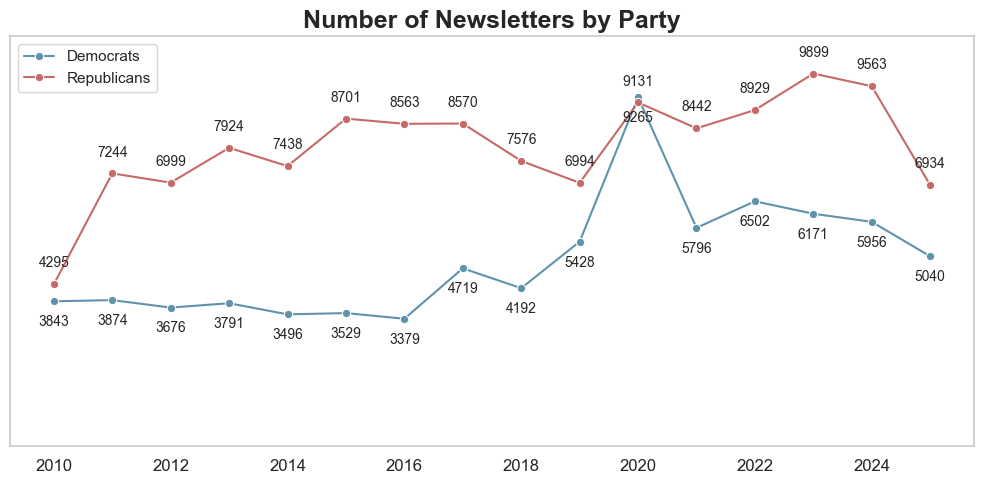

In [ ]:
# FIGURE: Newsletters by party and year

# Filter to only D and R politicians
party_and_year_df = dcinbox_df[dcinbox_df["Party"].isin(["D", "R"])]

# Group newsletters by date and party
yearly_newsletters = (
    party_and_year_df.groupby(["Year", "Party"], as_index=False)["Unix Timestamp"].count()
)

# Set the figure size
plt.figure(figsize=(10, 5))

# Plot the bars
ax = sns.lineplot(
    data=yearly_newsletters,
    x="Year",
    y="Unix Timestamp",
    hue="Party",
    palette={"D": dem_med_color, "R": rep_med_color},
    linewidth=2.5,
    marker="o",
    markersize=8 
)

# Legend formatting
# ax.legend(title=None)
handles, labels = ax.get_legend_handles_labels()
label_map = {"D": "Democrats", "R": "Republicans"}

ax.legend(
    handles,
    [label_map.get(l, l) for l in labels],
    title=None
)

# Add labels, title, and formatting
ax.grid(False, axis="x")
ax.set_xlabel(None)
ax.set_yticks([])
ax.set_ylabel(None)
# ax.set_ylim(bottom=0)
ax.set_ylim(0, yearly_newsletters["Unix Timestamp"].max() * 1.1)
plt.title("Number of Newsletters by Party", fontsize=18, fontweight="bold")

# Add data labels
# for container in ax.containers:
#     ax.bar_label(container, padding=3)
for line in ax.lines:
    color = line.get_color()
    if color == dem_med_color:
        dy = -10   # pixels DOWN
        va = "top"
    else:
        dy = 10    # pixels UP
        va = "bottom"
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        if pd.notna(y):
            text_transform = offset_copy(
                ax.transData,
                fig=ax.figure,
                y=dy,
                units="points"
            )
            ax.text(
                x,
                y,
                f"{int(y):,}",
                ha="center",
                va=va,
                transform=text_transform,
                fontsize=10
            )


# Set x-axis major ticks
# ax = plt.gca()  # get current axes
# ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation = 0, fontsize = 12)
plt.tight_layout()
plt.show()